# Virtual Analog Distortion

Virtual analog distortion emulates the nonlinear behaviour of electronic circuits using purely digital transfer curves. The two functions here model complementary types of analog saturation:

| Function | Description |
| --- | --- |
| `diode_clip` | Asymmetric soft-clipping modelling a series diode circuit. The positive half-cycle clips at a lower threshold than the negative half-cycle (asymmetric transfer curve), producing both **odd and even harmonics** — characteristically "buzzy" guitar-pedal distortion. |
| `analog_saturate` | Symmetric 3rd-order polynomial soft saturation: `y = 3x/2 · (1 − x²/3)` (scaled). Approximates a triode vacuum tube in its operating region. Produces **odd harmonics only** (3rd, 5th, …) — classic "warm" tube character. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.virtual_analog import analog_saturate, diode_clip

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Transfer curves, clipped waveforms, and harmonic spectra for both distortion models applied to a 440 Hz sine.

**2 × 4 grid:**

**Top row — diode_clip, three threshold values (1.0 / 0.7 / 0.4):**
- **Transfer curve:** asymmetric S-shape; the positive half saturates more aggressively than the negative half — characteristic of a forward-biased diode
- **Waveform:** visible asymmetry; positive peaks are more rounded/clipped than negative peaks
- **Spectrum:** both **odd and even harmonics** (2nd, 3rd, 4th, …) present due to the asymmetry; the 2nd harmonic is a distinctive "diode signature"
- **Harmonic amplitude vs order:** decays unevenly; even harmonics are at a similar level to odd ones

**Bottom row — analog_saturate, three drive values (1 / 3 / 8):**
- **Transfer curve:** smooth symmetric cubic S-curve; no asymmetry
- **Waveform:** symmetrically rounded peaks; no asymmetric distortion
- **Spectrum:** only **odd harmonics** (3rd, 5th, 7th); even harmonics are absent — this is the mathematical consequence of any odd (symmetric) transfer function applied to a sine
- **Harmonic amplitude vs order:** decays rapidly; 3rd harmonic dominates; very "tube-like" warmth

Asymmetric (even harmonic) distortion is characteristic of diodes and class-B push-pull amplifiers; symmetric (odd harmonic) distortion is characteristic of triode tubes and class-A amplifiers.


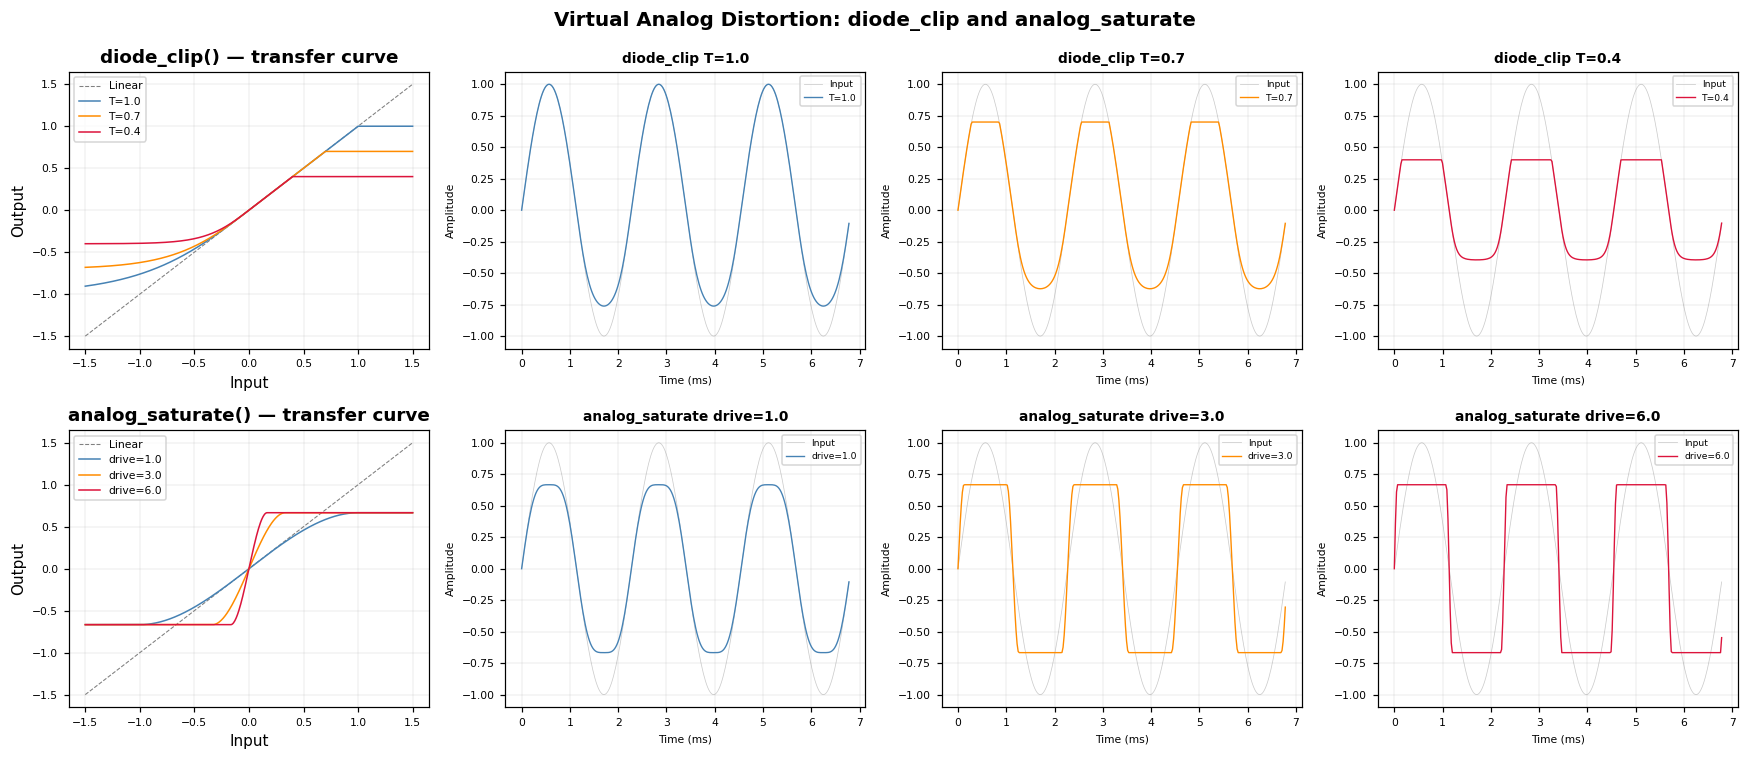

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 3 / FREQ

_, sig = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(sig)) / FS * 1000
x_tc = np.linspace(-1.5, 1.5, 500)

COLORS = ["steelblue", "darkorange", "crimson"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

# Transfer curves
ax = axes[0, 0]
ax.plot(x_tc, x_tc, color="gray", linewidth=0.7, linestyle="--", label="Linear")
for thresh, color in zip([1.0, 0.7, 0.4], COLORS):
    ax.plot(x_tc, diode_clip(x_tc, threshold=thresh), color=color, linewidth=1.0, label=f"T={thresh}")
ax.set_title("diode_clip() — transfer curve", fontweight="bold")
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.legend(fontsize=7)

ax = axes[1, 0]
ax.plot(x_tc, x_tc, color="gray", linewidth=0.7, linestyle="--", label="Linear")
for drive, color in zip([1.0, 3.0, 6.0], COLORS):
    ax.plot(x_tc, analog_saturate(x_tc * drive / drive, drive=drive), color=color, linewidth=1.0, label=f"drive={drive}")
ax.set_title("analog_saturate() — transfer curve", fontweight="bold")
ax.set_xlabel("Input")
ax.set_ylabel("Output")
ax.legend(fontsize=7)

# Waveforms
THRESHOLDS = [1.0, 0.7, 0.4]
DRIVES = [1.0, 3.0, 6.0]

for col, (thresh, color) in enumerate(zip(THRESHOLDS, COLORS), start=1):
    out = diode_clip(sig, threshold=thresh)
    axes[0, col].plot(t_ms, sig, color="gray", linewidth=0.5, alpha=0.4, label="Input")
    axes[0, col].plot(t_ms, out, color=color, linewidth=0.9, label=f"T={thresh}")
    axes[0, col].set_title(f"diode_clip T={thresh}", fontsize=9, fontweight="bold")
    axes[0, col].legend(fontsize=6)
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)
    axes[0, col].set_ylabel("Amplitude", fontsize=7)

for col, (drive, color) in enumerate(zip(DRIVES, COLORS), start=1):
    out = analog_saturate(sig, drive=drive)
    axes[1, col].plot(t_ms, sig, color="gray", linewidth=0.5, alpha=0.4, label="Input")
    axes[1, col].plot(t_ms, out, color=color, linewidth=0.9, label=f"drive={drive}")
    axes[1, col].set_title(f"analog_saturate drive={drive}", fontsize=9, fontweight="bold")
    axes[1, col].legend(fontsize=6)
    axes[1, col].set_xlabel("Time (ms)", fontsize=7)
    axes[1, col].set_ylabel("Amplitude", fontsize=7)

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.3, alpha=0.5)

fig.suptitle("Virtual Analog Distortion: diode_clip and analog_saturate", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()